This notebook demonstrates Polynomial Regression to model non-linear relationships using synthetic quadratic data y = 0.8x² + 0.9x + 2 + noise. It compares Linear Regression (R²=0.53) with Polynomial Regression (degree=2) which achieved R²=0.856, showing significant improvement. The implementation uses PolynomialFeatures, StandardScaler, and Pipeline with LinearRegression, along with SGDRegressor for gradient-based optimization. Visualizations clearly show polynomial curves fitting the data better than linear models, demonstrating how feature engineering captures complex patterns.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
import numpy as np
import random
import matplotlib.pyplot as plt



In [8]:
X =  6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 +np.random.randn(200,1)

# y= 0.8x^2 + 0.9x +2


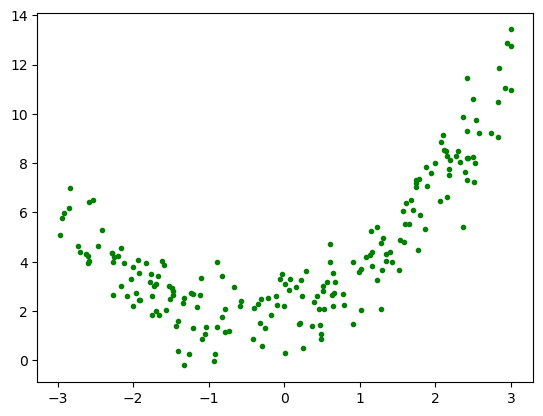

In [9]:
plt.plot(X,y,'g.')

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train,y_train)

LinearRegression()

In [14]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)


0.5304558036855921

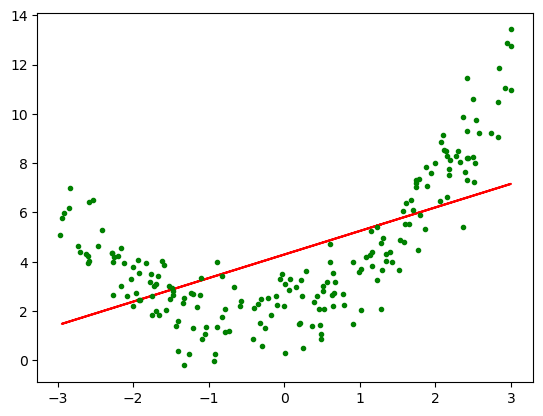

In [21]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,y,'g.')

In [23]:
# Applying polynomial Regresssion of degree = 2
poly = PolynomialFeatures(degree=2,include_bias=True) #include_bias =True includes the X^0 that is 1 to polynomial features

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [25]:
print(X_train[4])
print(X_train_trans[4]) 
print(X_test_trans[4]) 

[-1.51031787]
[ 1.         -1.51031787  2.28106006]
[1.         2.50984281 6.29931091]


In [27]:
lr= LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [29]:
y_pred=lr.predict(X_test_trans)

In [31]:
r2_score(y_test,y_pred)

0.8565678789275262

In [33]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.9168355  0.80999085]]
[1.95705852]


In [35]:
##Its purpose is to generate new input values, transform them into polynomial features, and predict the corresponding output values
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new_pred = lr.predict(x_new_poly)

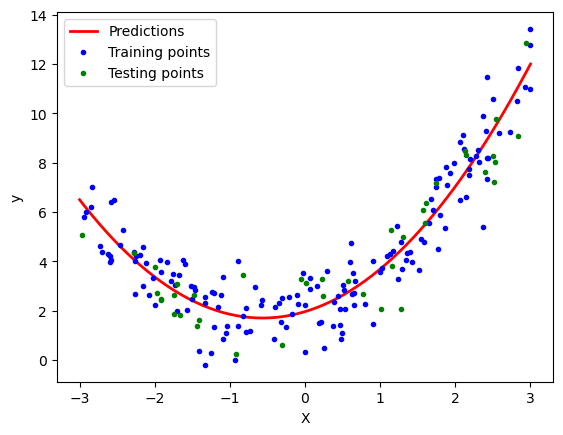

In [41]:
plt.plot(x_new, y_new_pred, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


In [88]:
def polynomial_regression(degree):
    x_new = np.linspace(-3,3,100).reshape(100,1)
    x_new_poly = poly.transform(x_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler= StandardScaler()
    lin_reg  = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly features",polybig_features),
        ("std_scaler",std_scaler),
        ("lin_regression",lin_reg),
    ])
    polynomial_regression.fit(X,y)
    y_newbig = polynomial_regression.predict(x_new)
    plt.plot(x_new,y_newbig,'r',label="Degree" + str(degree),linewidth=2)
    
    plt.plot(X_train,y_train,"b.",linewidth=3)
    plt.plot(X_test,y_test,"g.",linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

   
    

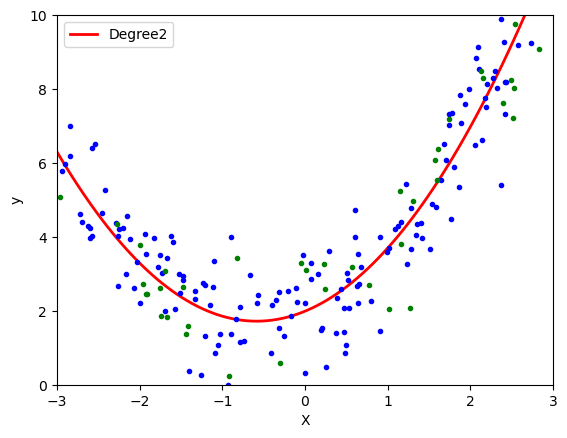

In [96]:
polynomial_regression(2)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


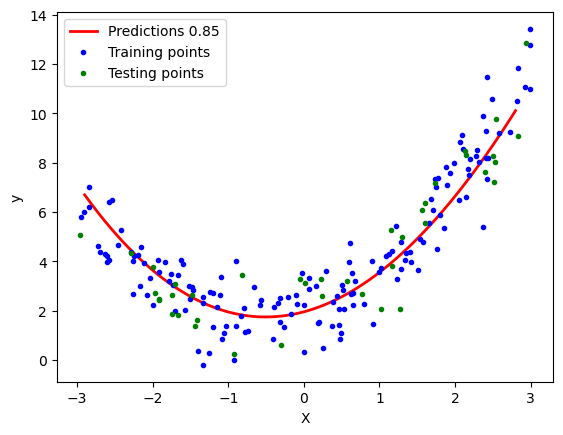

In [138]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=3)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()